<a href="https://colab.research.google.com/github/riotriw3/Convolutional-Neural-Network-CNN-for-CIFAR-10-Classification/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT UTS DEEP LEARNING**

# **CNN**

| Nama | NIM |
|----------|----------|
| Rio Tri Wibowo  | 11220940000004   |
| Aisya Shalifa  | 11220940000032   |


---

link RESNET: https://colab.research.google.com/drive/1E1gp6YALG4ByDvldNi9NMeoTMkEBILF0?usp=sharing

## Import Modul

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import uuid
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import cv2



In [ ]:
# hasil yang dihasilkan secara acak menjadi konsisten atau dapat direproduksi
torch.manual_seed(42)

In [ ]:
# menentukan apakah PyTorch akan menggunakan GPU (CUDA) atau CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Data preprocessing dan augmentasi
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# Transformasi untuk training (augmentasi + normalisasi)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Transformasi untuk testing (hanya normalisasi)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Unduh dan load CIFAR-10 dataset
full_train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Split manual: 80% train, 20% validasi
train_size = int(0.8 * len(full_train_dataset))  # 80% dari 50.000
val_size = len(full_train_dataset) - train_size  # sisanya untuk validasi
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

# DataLoader untuk train, val, dan test
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Kelas CIFAR-10
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


100%|██████████| 170M/170M [00:11<00:00, 14.4MB/s]


cat               cat               deer              frog             


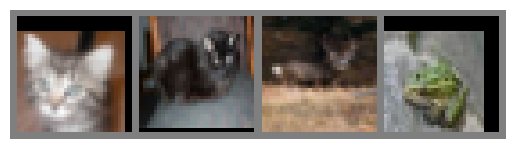

In [ ]:
# Fungsi untuk menampilkan gambar
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.savefig('preview_images.png')  # Save instead of show to match previous pattern

# Visualize some training images before model creation
dataiter = iter(train_loader)
images, labels = next(dataiter)
# Show only the first 4 images to keep the display manageable
imshow(torchvision.utils.make_grid(images[:4]))
print(' '.join(f'{class_names[labels[j]]:17s}' for j in range(4)))

In [ ]:
# Define custom CNN model
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)  # 3 input channels, 32 filters, 3x3 kernel
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # 32 input channels, 64 filters
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)  # 64 input channels, 128 filters
        self.pool = nn.MaxPool2d(2, 2)  # 2x2 max pooling
        self.bn1 = nn.BatchNorm2d(32)   # Batch normalization for conv1
        self.bn2 = nn.BatchNorm2d(64)  # Batch normalization for conv2
        self.bn3 = nn.BatchNorm2d(128)  # Batch normalization for conv3
        self.fc1 = nn.Linear(128 * 4 * 4, 256)  # Fully connected layer
        self.fc2 = nn.Linear(256, 10)   # Output layer for 10 classes
        self.dropout = nn.Dropout(0.5)  # Dropout for regularization

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # Conv1 -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # Conv2 -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # Conv3 -> BN -> ReLU -> Pool
        x = x.view(-1, 128 * 4 * 4)  # Flatten for fully connected layers
        x = F.relu(self.fc1(x))  # Fully connected layer with ReLU
        x = self.dropout(x)  # Apply dropout
        x = self.fc2(x)  # Output layer
        return x

In [ ]:
# Fungsi untuk komputasi prediksi dan true labels untuk dataset
def evaluate_predictions(model, dataloader):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images, targets = batch
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            predictions += preds.cpu().numpy().tolist()
            true_labels += targets.cpu().numpy().tolist()

    return np.array(predictions), np.array(true_labels)


In [ ]:
# Fungsi training dan evaluasi untuk early stopping
def run_training(model, train_loader, val_loader, test_loader, criterion, optimizer, epochs=15, patience=3):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        # ----- Training -----
        model.train()
        epoch_train_loss = 0.0
        correct_train, total_train = 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            predictions = model(inputs)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            _, preds = predictions.max(1)
            total_train += labels.size(0)
            correct_train += preds.eq(labels).sum().item()

        train_loss = epoch_train_loss / len(train_loader)
        train_accuracy = 100. * correct_train / total_train
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # ----- Validation -----
        model.eval()
        epoch_val_loss = 0.0
        correct_val, total_val = 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                val_preds = model(inputs)
                val_loss = criterion(val_preds, labels)

                epoch_val_loss += val_loss.item()
                _, preds = val_preds.max(1)
                total_val += labels.size(0)
                correct_val += preds.eq(labels).sum().item()


        val_loss = epoch_val_loss / len(val_loader)
        val_accuracy = 100. * correct_val / total_val
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"[Epoch {epoch+1}] Train Loss: {train_loss:.3f}, Train Acc: {train_accuracy:.2f}% | "
              f"Val Loss: {val_loss:.3f}, Val Acc: {val_accuracy:.2f}%")

        # ----- Early Stopping Check -----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    # ----- Test Evaluation -----
    model.eval()
    correct_test, total_test = 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            test_preds = model(inputs)
            _, preds = test_preds.max(1)
            total_test += labels.size(0)
            correct_test += preds.eq(labels).sum().item()

    test_accuracy = 100. * correct_test / total_test
    print(f"\nFinal Test Accuracy: {test_accuracy:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies, test_accuracy


In [ ]:
# Hyperparameter tuning with 10 epochs and early stopping
learning_rates = [0.001, 0.003]
batch_sizes = [32, 64]
best_val_acc = 0
best_params = {}
best_model = None

for lr in learning_rates:
    for bs in batch_sizes:
        print(f'\nTuning: lr={lr}, batch_size={bs}')
        trainloader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        valloader = DataLoader(val_dataset, batch_size=bs, shuffle=False)
        model = CustomCNN().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        train_losses, val_losses, train_accs, val_accs, test_acc = run_training(model, trainloader, valloader, test_loader, criterion, optimizer, epochs=10, patience=3)
        if val_accs[-1] > best_val_acc:
            best_val_acc = val_accs[-1]
            best_params = {'lr': lr, 'batch_size': bs}
            best_model = model
            best_train_losses, best_val_losses, best_train_accs, best_val_accs, best_test_acc = train_losses, val_losses, train_accs, val_accs, test_acc

print(f'\nHyperparameters terbaik: {best_params}')


Tuning: lr=0.001, batch_size=32
[Epoch 1] Train Loss: 1.649, Train Acc: 38.43% | Val Loss: 1.343, Val Acc: 50.99%
[Epoch 2] Train Loss: 1.366, Train Acc: 50.42% | Val Loss: 1.112, Val Acc: 60.22%
[Epoch 3] Train Loss: 1.231, Train Acc: 56.06% | Val Loss: 1.013, Val Acc: 63.42%
[Epoch 4] Train Loss: 1.142, Train Acc: 59.28% | Val Loss: 0.959, Val Acc: 65.58%
[Epoch 5] Train Loss: 1.078, Train Acc: 62.00% | Val Loss: 0.881, Val Acc: 68.82%
[Epoch 6] Train Loss: 1.021, Train Acc: 64.11% | Val Loss: 0.845, Val Acc: 69.77%
[Epoch 7] Train Loss: 0.985, Train Acc: 65.78% | Val Loss: 0.811, Val Acc: 71.26%
[Epoch 8] Train Loss: 0.942, Train Acc: 67.06% | Val Loss: 0.806, Val Acc: 71.50%
[Epoch 9] Train Loss: 0.905, Train Acc: 68.35% | Val Loss: 0.771, Val Acc: 72.84%
[Epoch 10] Train Loss: 0.880, Train Acc: 69.60% | Val Loss: 0.736, Val Acc: 74.33%

Final Test Accuracy: 76.41%

Tuning: lr=0.001, batch_size=64
[Epoch 1] Train Loss: 1.607, Train Acc: 40.83% | Val Loss: 1.339, Val Acc: 51.82%
[E

In [ ]:
# Training akhir dengan hyperparameter terbaik
print('\nFinal training with best hyperparameters...')
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False)
model = CustomCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
train_losses, val_losses, train_accuracies, val_accuracies, test_accuracy = run_training(model, train_loader, val_loader, test_loader, criterion, optimizer, epochs=20, patience=3)


Final training with best hyperparameters...
[Epoch 1] Train Loss: 1.658, Train Acc: 38.04% | Val Loss: 1.292, Val Acc: 53.20%
[Epoch 2] Train Loss: 1.366, Train Acc: 50.23% | Val Loss: 1.154, Val Acc: 58.30%
[Epoch 3] Train Loss: 1.239, Train Acc: 55.68% | Val Loss: 1.077, Val Acc: 60.84%
[Epoch 4] Train Loss: 1.158, Train Acc: 58.89% | Val Loss: 0.921, Val Acc: 66.58%
[Epoch 5] Train Loss: 1.095, Train Acc: 61.30% | Val Loss: 0.921, Val Acc: 67.05%
[Epoch 6] Train Loss: 1.043, Train Acc: 63.54% | Val Loss: 0.849, Val Acc: 69.59%
[Epoch 7] Train Loss: 1.002, Train Acc: 64.97% | Val Loss: 0.811, Val Acc: 71.30%
[Epoch 8] Train Loss: 0.965, Train Acc: 66.50% | Val Loss: 0.828, Val Acc: 70.52%
[Epoch 9] Train Loss: 0.936, Train Acc: 67.68% | Val Loss: 0.765, Val Acc: 72.94%
[Epoch 10] Train Loss: 0.903, Train Acc: 68.62% | Val Loss: 0.735, Val Acc: 74.81%
[Epoch 11] Train Loss: 0.875, Train Acc: 70.07% | Val Loss: 0.768, Val Acc: 72.35%
[Epoch 12] Train Loss: 0.847, Train Acc: 70.81% | V

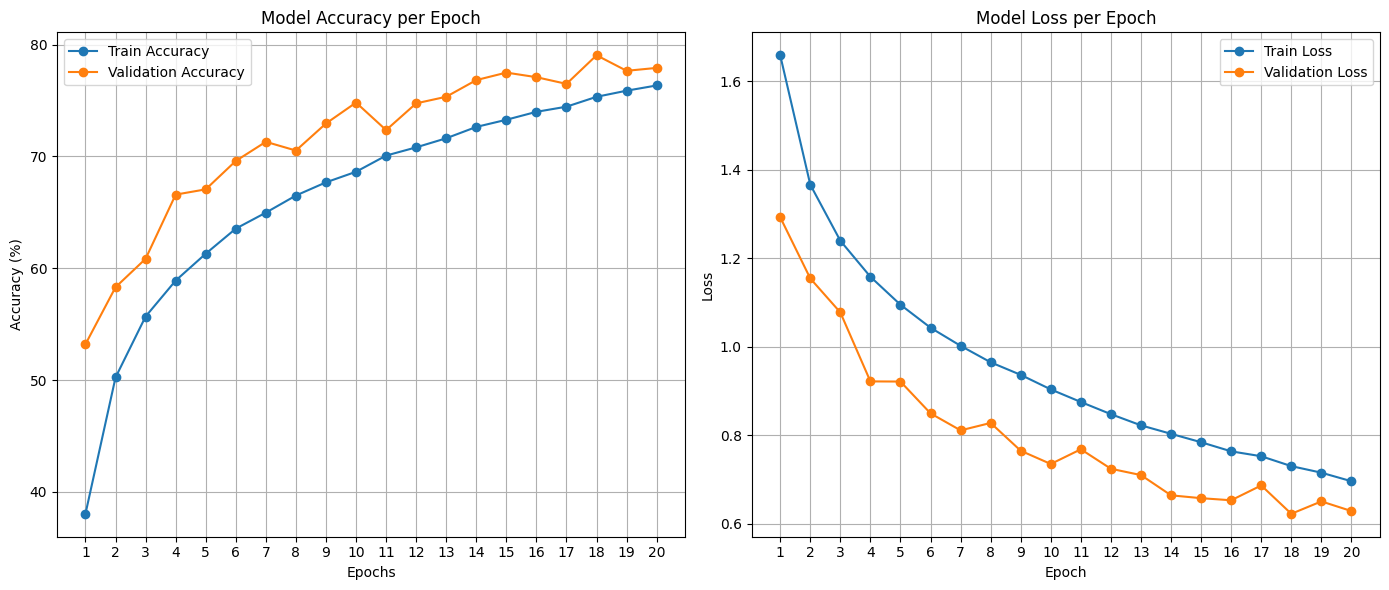

In [ ]:

epochs_trained = len(train_accuracies) # atau len(val_accuracies), harusnya sama
epochs_range = range(1, epochs_trained + 1)

plt.figure(figsize=(14, 6))

# Plotting acc
plt.subplot(1, 2, 1)
# Use train_accuracies and val_accuracies from the final training run
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', marker='o') # Corrected label to 'Validation Accuracy' based on code
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range) # Menampilkan semua nomor epoch di sumbu X jika tidak terlalu banyak
plt.legend()
plt.grid(True)

# Plotting loss
plt.subplot(1, 2, 2)
# Use train_losses and val_losses from the final training run
plt.plot(epochs_range, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', marker='o') # Corrected label to 'Validation Loss' based on code
plt.title('Model Loss per Epoch') # Corrected typo 'oer' to 'per'
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_range) # Menampilkan semua nomor epoch di sumbu X
plt.legend()
plt.grid(True)

plt.tight_layout() # Menyesuaikan layout agar tidak tumpang tindih
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch.nn.functional as F

def visualize_feature_maps(model, img, true_label, pred_label, class_names, device, num_filters=8):
    model.eval()
    img = img.to(device).unsqueeze(0)

    # Daftar layer konvolusi
    conv_layers = [model.conv1, model.conv2, model.conv3]
    norm_layers = [model.bn1, model.bn2, model.bn3]

    x = img
    feature_maps_all = []

    # Ambil feature map dari setiap conv layer
    for i, conv in enumerate(conv_layers):
        x = conv(x)
        x = norm_layers[i](x)
        x = F.relu(x)
        fmap = x[0].detach().cpu().numpy()
        feature_maps_all.append(fmap)

    # Convert input image untuk overlay (dari tensor ke numpy)
    img_np = img[0].cpu().permute(1, 2, 0).numpy()
    img_np = (img_np / 2 + 0.5) * 255
    img_np = img_np.astype(np.uint8)

    # Plot
    fig, axes = plt.subplots(len(feature_maps_all) + 1, num_filters, figsize=(num_filters * 2, 10))
    fig.suptitle(f"Ground Truth: {class_names[true_label]} | Predicted: {class_names[pred_label]}", fontsize=16)

    # Tampilkan gambar asli
    for i in range(num_filters):
        if i == 0:
            axes[0, i].imshow(img_np)
            axes[0, i].set_title("Input Image")
        else:
            axes[0, i].axis("off")

    # Tampilkan feature maps
    for layer_idx, fmap in enumerate(feature_maps_all):
        for i in range(num_filters):
            fmap_i = fmap[i]
            fmap_norm = cv2.normalize(fmap_i, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            heatmap = cv2.applyColorMap(fmap_norm, cv2.COLORMAP_JET)
            overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)
            overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
            axes[layer_idx + 1, i].imshow(overlay)
            axes[layer_idx + 1, i].set_title(f"Layer {layer_idx+1} | F{i}")
            axes[layer_idx + 1, i].axis("off")

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig("feature_map_overlay_visual.png")
    plt.show()


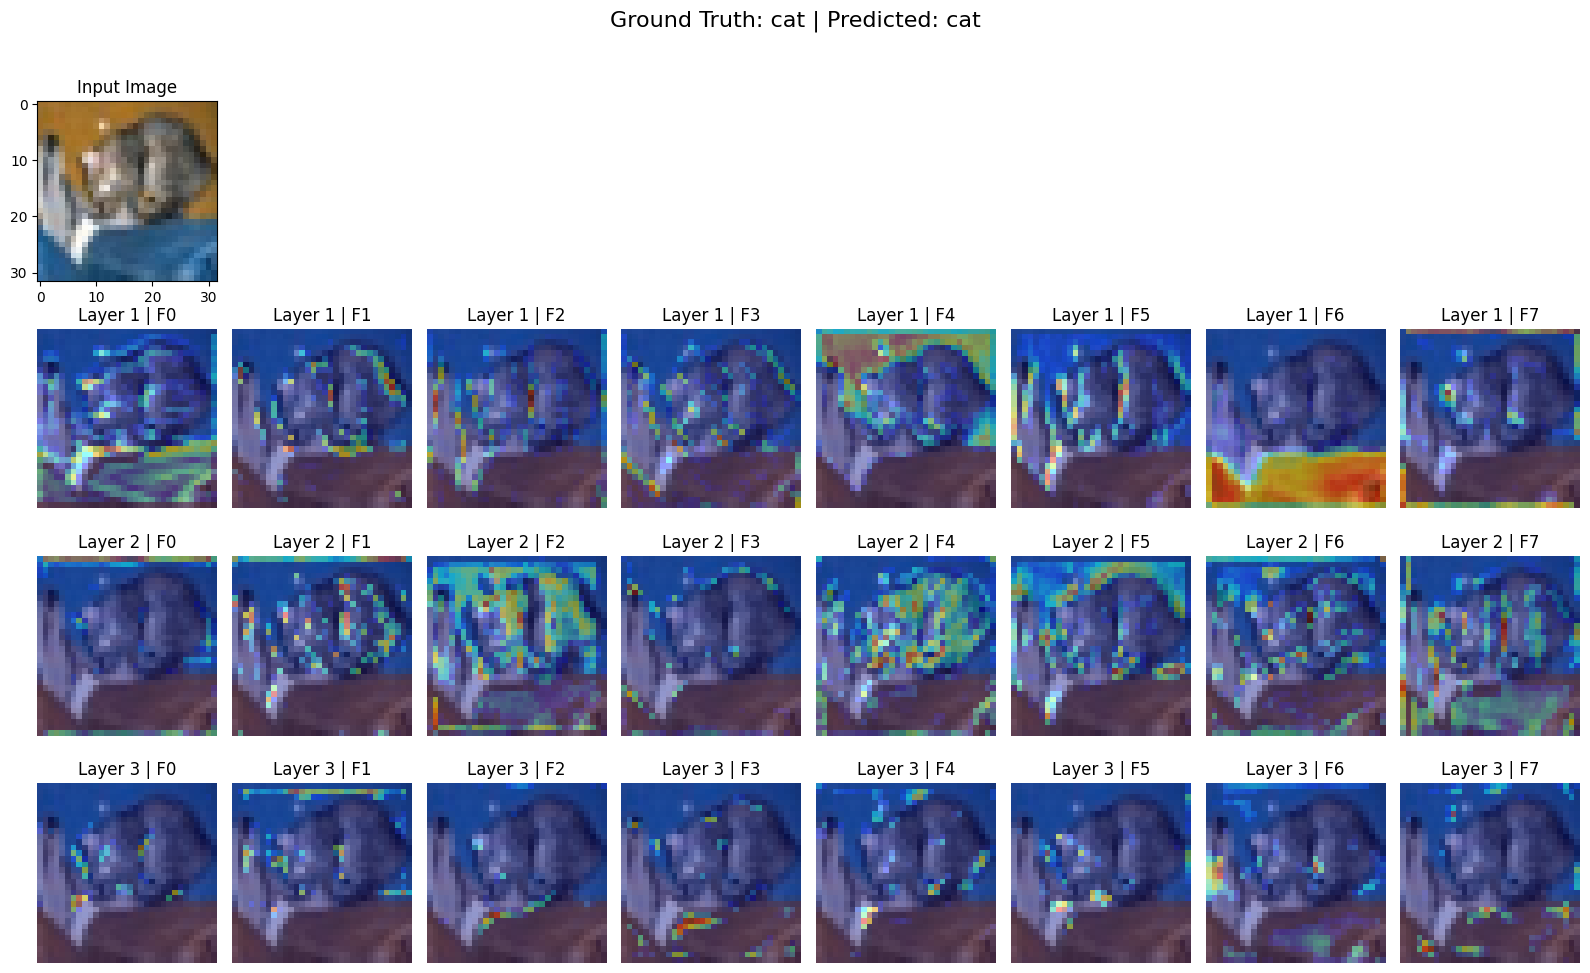

In [ ]:
# Get a batch from the test loader
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Select the first image from the batch
img = images[0]
true_label = labels[0].item()

# Get the model's prediction for this image
model.eval() # Set the model to evaluation mode
with torch.no_grad():
    img_for_pred = img.unsqueeze(0).to(device) # Add batch dimension and move to device
    outputs = model(img_for_pred)
    _, predicted = torch.max(outputs.data, 1)
    pred_label = predicted.item()

# Now call the visualize_feature_maps function with the obtained variables
visualize_feature_maps(model, img, true_label, pred_label, class_names, device)

In [ ]:
# Fungsi untuk mengumpulkan prediksi dan label dari dataloader
def predictions_and_labels(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            test_preds = model(inputs)
            _, preds = test_preds.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

In [ ]:
# Hitung prediksi dan label untuk train, val, dan test set
train_preds, train_labels = predictions_and_labels(model, train_loader)
val_preds, val_labels = predictions_and_labels(model, val_loader)
test_preds, test_labels = predictions_and_labels(model, test_loader)

# Hitung akurasi akhir untuk semua set
train_acc_final = 100. * (train_preds == train_labels).sum() / len(train_labels)
val_acc_final = 100. * (val_preds == val_labels).sum() / len(val_labels)
test_acc_final = 100. * (test_preds == test_labels).sum() / len(test_labels)

In [ ]:
# Tampilkan akurasi akhir
print('\nFinal Accuracies:')
print(f'Training Accuracy: {train_acc_final:.2f}%')
print(f'Validation Accuracy: {val_acc_final:.2f}%')
print(f'Test Accuracy: {test_acc_final:.2f}%')


Final Accuracies:
Training Accuracy: 80.66%
Validation Accuracy: 78.48%
Test Accuracy: 79.86%


In [ ]:
# Impor library tambahan
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import seaborn as sns

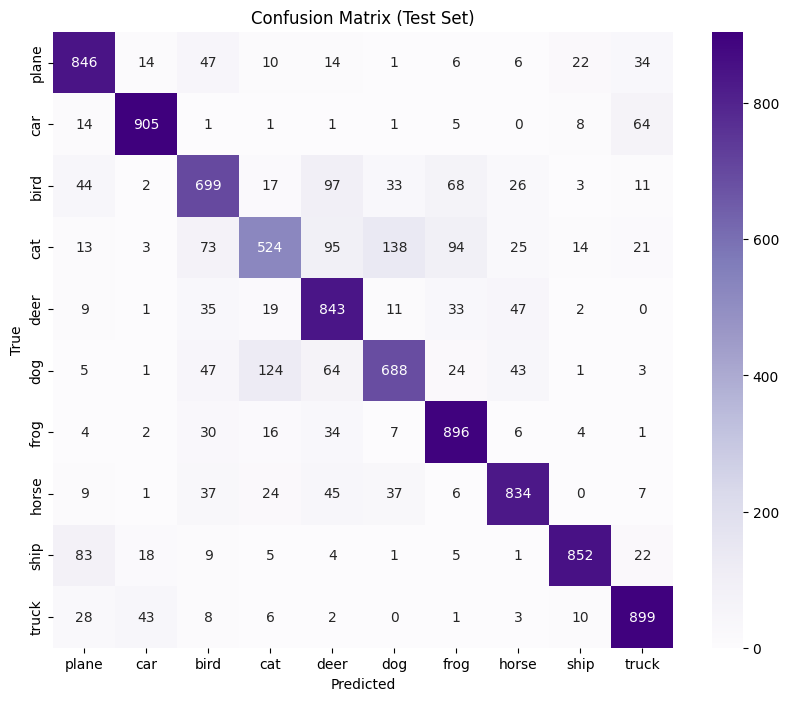

In [ ]:
# Confusion Matrix untuk Test Set
cm = confusion_matrix(test_labels, test_preds)
# Visualisasi Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_matrix.png')


In [ ]:
# Precision, Recall, dan F1-Score untuk Test Set
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average=None)
print('\nPer-Class Metrics (Test Set):')
for i, class_name in enumerate(class_names):
    print(f'{class_name:17s}: Precision: {precision[i]:.3f}, Recall: {recall[i]:.3f}, F1-Score: {f1[i]:.3f}')


Per-Class Metrics (Test Set):
plane            : Precision: 0.802, Recall: 0.846, F1-Score: 0.823
car              : Precision: 0.914, Recall: 0.905, F1-Score: 0.910
bird             : Precision: 0.709, Recall: 0.699, F1-Score: 0.704
cat              : Precision: 0.702, Recall: 0.524, F1-Score: 0.600
deer             : Precision: 0.703, Recall: 0.843, F1-Score: 0.767
dog              : Precision: 0.750, Recall: 0.688, F1-Score: 0.718
frog             : Precision: 0.787, Recall: 0.896, F1-Score: 0.838
horse            : Precision: 0.842, Recall: 0.834, F1-Score: 0.838
ship             : Precision: 0.930, Recall: 0.852, F1-Score: 0.889
truck            : Precision: 0.847, Recall: 0.899, F1-Score: 0.872
